# Skin Cancer Detection: End-to-End Deep Learning Pipeline
Dataset: `fatemehmehrparvar/skin-cancer-detection` (Kaggle, via `kagglehub`)

**Pipeline:** Acquisition → Visualization → Cleaning → Feature Engineering → Splitting → Training (3 models) → Testing + Confusion Matrix → Results Comparison → Best Model Export for Streamlit Cloud

> Tip: Runtime → Change runtime type → **T4 GPU** before running.

## 0. Setup

In [33]:
!pip -q install kagglehub

import os, json, hashlib, random, shutil, zipfile, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_curve, auc)

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
sns.set_style("whitegrid")

# ---- Global config (edit here) ----
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_CNN = 40     # custom CNN trained from scratch
EPOCHS_HEAD = 8     # transfer learning: train classifier head
EPOCHS_FT = 8       # transfer learning: fine-tune top layers
MIN_IMAGES_PER_CLASS = 10

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Dataset Acquisition

In [34]:
import kagglehub

path = kagglehub.dataset_download("fatemehmehrparvar/skin-cancer-detection")
print("Path to dataset files:", path)

# Show the folder structure (top levels)
def show_tree(root, max_depth=3, max_items=8):
    root = Path(root)
    for dirpath, dirnames, filenames in os.walk(root):
        depth = len(Path(dirpath).relative_to(root).parts)
        if depth > max_depth:
            dirnames[:] = []
            continue
        print("  " * depth + f"📁 {Path(dirpath).name}/  ({len(filenames)} files)")
        for f in filenames[:2]:
            print("  " * (depth + 1) + f)

show_tree(path)

Using Colab cache for faster access to the 'skin-cancer-detection' dataset.
Path to dataset files: /kaggle/input/skin-cancer-detection
📁 skin-cancer-detection/  (0 files)
  📁 skin_image_data_set-2/  (0 files)
    📁 Skin Image Data Set-2/  (0 files)
      📁 skin_data/  (0 files)
  📁 skin_image_data_set-1/  (0 files)
    📁 Skin Image Data Set-1/  (0 files)
      📁 skin_data/  (0 files)


In [35]:
# Build a dataframe of (filepath, label). Label = name of the class folder that holds the image.
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
SPLIT_NAMES = {"train", "test", "val", "valid", "validation", "training", "testing"}

rows = []
for p in Path(path).rglob("*"):
    if p.is_file() and p.suffix.lower() in IMG_EXT:
        parts = [x for x in p.parent.relative_to(path).parts]
        # class folder = closest parent folder that isn't a train/test/val folder
        cls = next((x for x in reversed(parts) if x.lower() not in SPLIT_NAMES), None)
        if cls is None:
            continue
        rows.append({"filepath": str(p), "label": cls.strip().lower()})

df = pd.DataFrame(rows)
print("Total images found:", len(df))
print(df["label"].value_counts())
assert len(df) > 0, "No images found - check the folder structure printed above."
assert df["label"].nunique() > 1, "Only one class detected - labels may not come from folder names; inspect the tree above."
df.head()

Total images found: 412
label
dermquest    274
dermis       138
Name: count, dtype: int64


,filepath,label
0,/kaggle/input/skin-cancer-detection/skin_image...,dermquest
1,/kaggle/input/skin-cancer-detection/skin_image...,dermquest
2,/kaggle/input/skin-cancer-detection/skin_image...,dermquest
3,/kaggle/input/skin-cancer-detection/skin_image...,dermquest
4,/kaggle/input/skin-cancer-detection/skin_image...,dermquest


## 2. Dataset Visualization

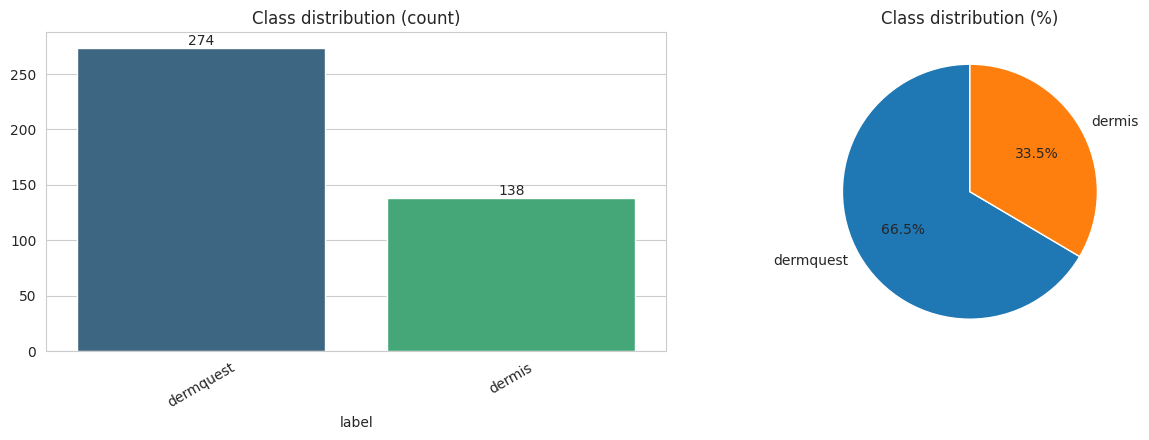

In [36]:
# 2.1 Class distribution
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
counts = df["label"].value_counts()
sns.barplot(x=counts.index, y=counts.values, ax=ax[0], palette="viridis")
ax[0].set_title("Class distribution (count)")
for i, v in enumerate(counts.values):
    ax[0].text(i, v, str(v), ha="center", va="bottom")
ax[0].tick_params(axis="x", rotation=30)
ax[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90)
ax[1].set_title("Class distribution (%)")
plt.tight_layout(); plt.show()

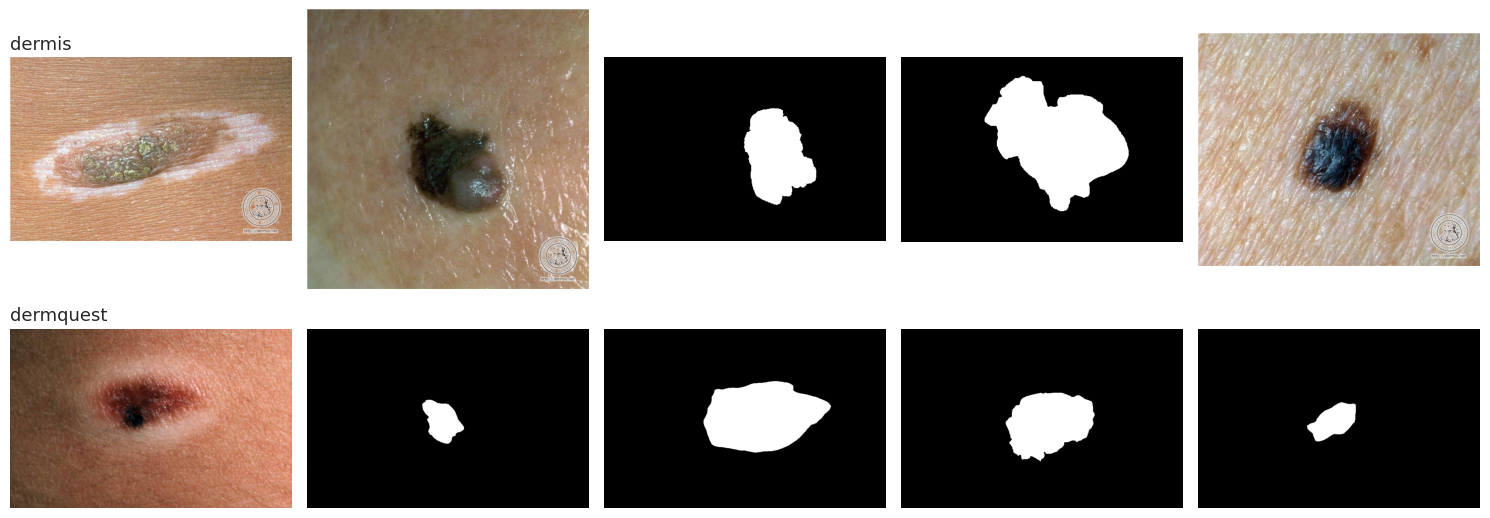

In [37]:
# 2.2 Sample images per class
classes = sorted(df["label"].unique())
n_per_class = 5
fig, axes = plt.subplots(len(classes), n_per_class, figsize=(3 * n_per_class, 3 * len(classes)), squeeze=False)
for r, c in enumerate(classes):
    samp = df[df.label == c].sample(min(n_per_class, (df.label == c).sum()), random_state=SEED)
    for k in range(n_per_class):
        axes[r, k].axis("off")
        if k < len(samp):
            axes[r, k].imshow(Image.open(samp.iloc[k].filepath).convert("RGB"))
            if k == 0:
                axes[r, k].set_title(c, fontsize=13, loc="left")
plt.tight_layout(); plt.show()

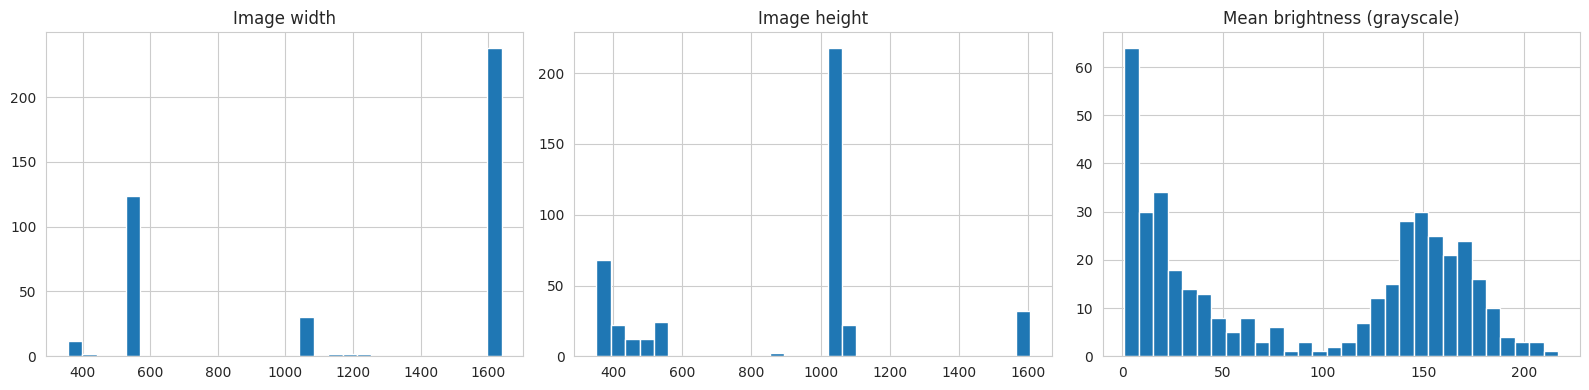

Unique sizes in sample: 53


In [38]:
# 2.3 Image size & brightness statistics (sample up to 600 images)
sample = df.sample(min(600, len(df)), random_state=SEED)
widths, heights, brightness = [], [], []
for fp in sample.filepath:
    try:
        with Image.open(fp) as im:
            widths.append(im.size[0]); heights.append(im.size[1])
            brightness.append(np.asarray(im.convert("L").resize((64, 64))).mean())
    except Exception:
        pass
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(widths, bins=30); ax[0].set_title("Image width")
ax[1].hist(heights, bins=30); ax[1].set_title("Image height")
ax[2].hist(brightness, bins=30); ax[2].set_title("Mean brightness (grayscale)")
plt.tight_layout(); plt.show()
print(f"Unique sizes in sample: {len(set(zip(widths, heights)))}")

## 3. Dataset Cleaning
Removes unreadable/corrupt files, tiny images, exact duplicates (MD5) and ultra-rare classes.

In [39]:
def md5(fp, chunk=1 << 20):
    h = hashlib.md5()
    with open(fp, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b: break
            h.update(b)
    return h.hexdigest()

n0 = len(df)
bad, small = [], []
for i, fp in enumerate(df.filepath):
    try:
        with Image.open(fp) as im:
            im.verify()
        with Image.open(fp) as im:
            w, h = im.size
            if min(w, h) < 32:
                small.append(fp)
    except (UnidentifiedImageError, OSError, ValueError):
        bad.append(fp)

df = df[~df.filepath.isin(set(bad) | set(small))].copy()
print(f"Corrupt removed: {len(bad)} | Too small removed: {len(small)}")

# Duplicates (same content). If the same file appears under different labels, drop all copies (ambiguous).
df["hash"] = df.filepath.map(md5)
conflict_hashes = df.groupby("hash")["label"].nunique()
conflict_hashes = set(conflict_hashes[conflict_hashes > 1].index)
df = df[~df.hash.isin(conflict_hashes)]
dups = df.duplicated("hash").sum()
df = df.drop_duplicates("hash").drop(columns="hash").reset_index(drop=True)
print(f"Label-conflicting duplicate groups removed: {len(conflict_hashes)} | Exact duplicates removed: {dups}")

# Rare classes
vc = df.label.value_counts()
rare = vc[vc < MIN_IMAGES_PER_CLASS].index.tolist()
if rare:
    print("Dropping rare classes:", rare)
    df = df[~df.label.isin(rare)].reset_index(drop=True)

print(f"\nImages: {n0} -> {len(df)}")
print(df.label.value_counts())

Corrupt removed: 0 | Too small removed: 0
Label-conflicting duplicate groups removed: 0 | Exact duplicates removed: 0

Images: 412 -> 412
label
dermquest    274
dermis       138
Name: count, dtype: int64


## 4. Feature Engineering
- Label encoding
- Class weights (handles class imbalance)
- Resize to 224×224, scaling/normalization and data augmentation (both built *inside* the models so deployment needs no extra preprocessing)

Classes: {'dermis': 0, 'dermquest': 1}
Class weights: {0: 1.4927536231884058, 1: 0.7518248175182481}


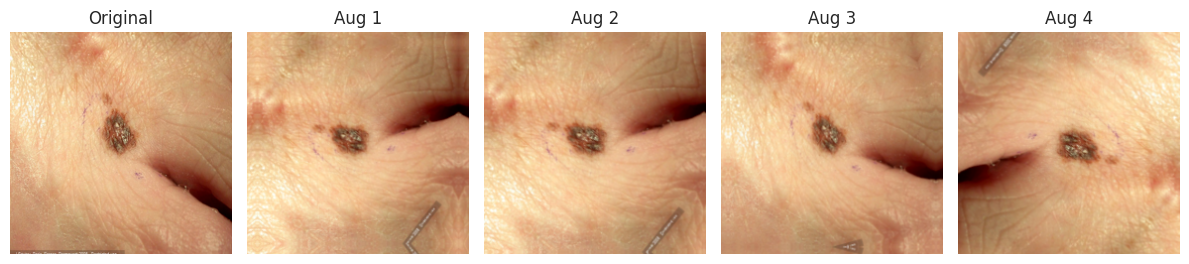

In [40]:
class_names = sorted(df.label.unique())
class_to_idx = {c: i for i, c in enumerate(class_names)}
df["y"] = df.label.map(class_to_idx)
NUM_CLASSES = len(class_names)
print("Classes:", class_to_idx)

weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=df.y.values)
class_weight = {i: float(w) for i, w in enumerate(weights)}
print("Class weights:", class_weight)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name="augmentation")

# Preview augmentation
img = np.asarray(Image.open(df.filepath.iloc[0]).convert("RGB").resize((IMG_SIZE, IMG_SIZE)), dtype="float32")
plt.figure(figsize=(12, 3))
plt.subplot(1, 5, 1); plt.imshow(img.astype("uint8")); plt.title("Original"); plt.axis("off")
for i in range(4):
    plt.subplot(1, 5, i + 2)
    plt.imshow(data_augmentation(img[None], training=True)[0].numpy().astype("uint8")); plt.axis("off"); plt.title(f"Aug {i+1}")
plt.tight_layout(); plt.show()

## 5. Dataset Splitting
Stratified **70% train / 15% validation / 15% test** (split after de-duplication, so no leakage).

Train: 288 | Val: 62 | Test: 62


,train,val,test
label,,,
dermquest,192,41,41
dermis,96,21,21


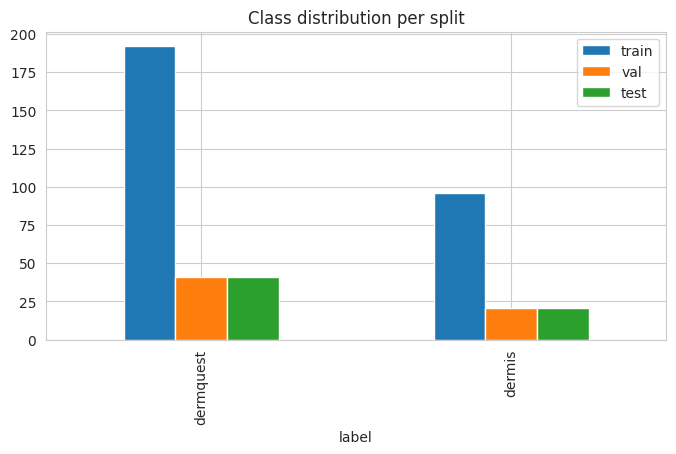

In [41]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df.y, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df.y, random_state=SEED)
train_df, val_df, test_df = [d.reset_index(drop=True) for d in (train_df, val_df, test_df)]

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
split_summary = pd.DataFrame({
    "train": train_df.label.value_counts(),
    "val": val_df.label.value_counts(),
    "test": test_df.label.value_counts(),
})
display(split_summary)
split_summary.plot(kind="bar", figsize=(8, 4), title="Class distribution per split"); plt.show()

In [42]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(fp, y):
    img = tf.io.read_file(fp)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return tf.cast(img, tf.float32), y   # raw 0-255 pixels; scaling happens inside the model

def make_ds(frame, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((frame.filepath.values, frame.y.values.astype("int32")))
    if shuffle:
        ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_df, shuffle=True)
val_ds = make_ds(val_df)
test_ds = make_ds(test_df)   # not shuffled -> order matches test_df

## 6. Model Training
Three models are trained and compared:
1. **Custom CNN** (from scratch)
2. **MobileNetV2** (transfer learning, small & fast: great for Streamlit Cloud)
3. **EfficientNetB0** (transfer learning)

Transfer models: stage 1 trains the head with a frozen backbone, stage 2 fine-tunes the top layers at a low learning rate.

In [43]:
def build_cnn():
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inp)
    x = layers.Rescaling(1.0 / 255)(x)
    for f in (16,32,128):
        x = layers.Conv2D(f, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(f,3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(0.2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inp, out, name="custom_cnn"), None

def build_mobilenet():
    base = keras.applications.MobileNetV2(include_top=False, weights="imagenet",
                                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inp)
    x = layers.Rescaling(1.0 / 127.5, offset=-1)(x)    # MobileNetV2 preprocessing
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inp, out, name="mobilenetv2"), base

def build_efficientnet():
    base = keras.applications.EfficientNetB0(include_top=False, weights="imagenet",
                                             input_shape=(IMG_SIZE, IMG_SIZE, 3))  # has built-in preprocessing
    base.trainable = False
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inp)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inp, out, name="efficientnetb0"), base

def compile_model(m, lr):
    m.compile(optimizer=keras.optimizers.Adam(lr),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

def get_callbacks(patience=4):
    return [keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7)]

def merge_hist(*hs):
    out = {}
    for h in hs:
        for k, v in h.history.items():
            out.setdefault(k, []).extend(v)
    return out

def train_model(builder, name):
    print(f"\n{'='*20} Training {name} {'='*20}")
    model, base = builder()
    if base is None:                                   # from-scratch CNN
        compile_model(model, 5e-4)
        h = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_CNN,
                      class_weight=class_weight, callbacks=get_callbacks(patience=10), verbose=2)
        return model, merge_hist(h)
    # Stage 1: head only
    compile_model(model, 1e-3)
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
                   class_weight=class_weight, callbacks=get_callbacks(), verbose=2)
    # Stage 2: fine-tune top layers (BatchNorm stays frozen)
    base.trainable = True
    for l in base.layers[:-30]:
        l.trainable = False
    for l in base.layers:
        if isinstance(l, layers.BatchNormalization):
            l.trainable = False
    compile_model(model, 1e-5)
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FT,
                   class_weight=class_weight, callbacks=get_callbacks(), verbose=2)
    return model, merge_hist(h1, h2)

models, histories = {}, {}
for name, builder in [("Custom CNN", build_cnn),
                      ("MobileNetV2", build_mobilenet),
                      ("EfficientNetB0", build_efficientnet)]:
    models[name], histories[name] = train_model(builder, name)


==================== Training Custom CNN ====================
Epoch 1/40
9/9 - 15s - 2s/step - accuracy: 0.6458 - loss: 0.7412 - val_accuracy: 0.5968 - val_loss: 0.6944 - learning_rate: 5.0000e-04
Epoch 2/40
9/9 - 3s - 333ms/step - accuracy: 0.6667 - loss: 0.6308 - val_accuracy: 0.3387 - val_loss: 0.7062 - learning_rate: 5.0000e-04
Epoch 3/40
9/9 - 4s - 471ms/step - accuracy: 0.7431 - loss: 0.5330 - val_accuracy: 0.3387 - val_loss: 0.7175 - learning_rate: 5.0000e-04
Epoch 4/40
9/9 - 3s - 278ms/step - accuracy: 0.7882 - loss: 0.4702 - val_accuracy: 0.3387 - val_loss: 0.7352 - learning_rate: 1.5000e-04
Epoch 5/40
9/9 - 2s - 232ms/step - accuracy: 0.8056 - loss: 0.4733 - val_accuracy: 0.3387 - val_loss: 0.7568 - learning_rate: 1.5000e-04
Epoch 6/40
9/9 - 2s - 257ms/step - accuracy: 0.7743 - loss: 0.4881 - val_accuracy: 0.3387 - val_loss: 0.7834 - learning_rate: 4.5000e-05
Epoch 7/40
9/9 - 3s - 340ms/step - accuracy: 0.8021 - loss: 0.4614 - val_accuracy: 0.3387 - val_loss: 0.8156 - learni

## 7. Model Testing (with Confusion Matrix)


=============== Custom CNN ===============
              precision    recall  f1-score   support

      dermis     0.4483    0.6190    0.5200        21
   dermquest     0.7576    0.6098    0.6757        41

    accuracy                         0.6129        62
   macro avg     0.6029    0.6144    0.5978        62
weighted avg     0.6528    0.6129    0.6229        62



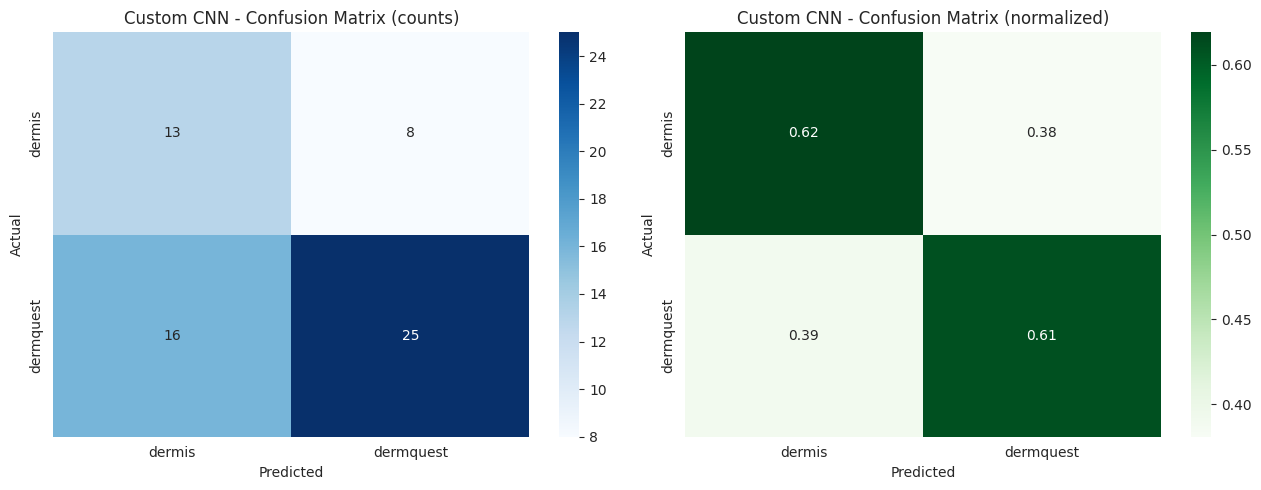


=============== MobileNetV2 ===============
              precision    recall  f1-score   support

      dermis     0.9130    1.0000    0.9545        21
   dermquest     1.0000    0.9512    0.9750        41

    accuracy                         0.9677        62
   macro avg     0.9565    0.9756    0.9648        62
weighted avg     0.9705    0.9677    0.9681        62



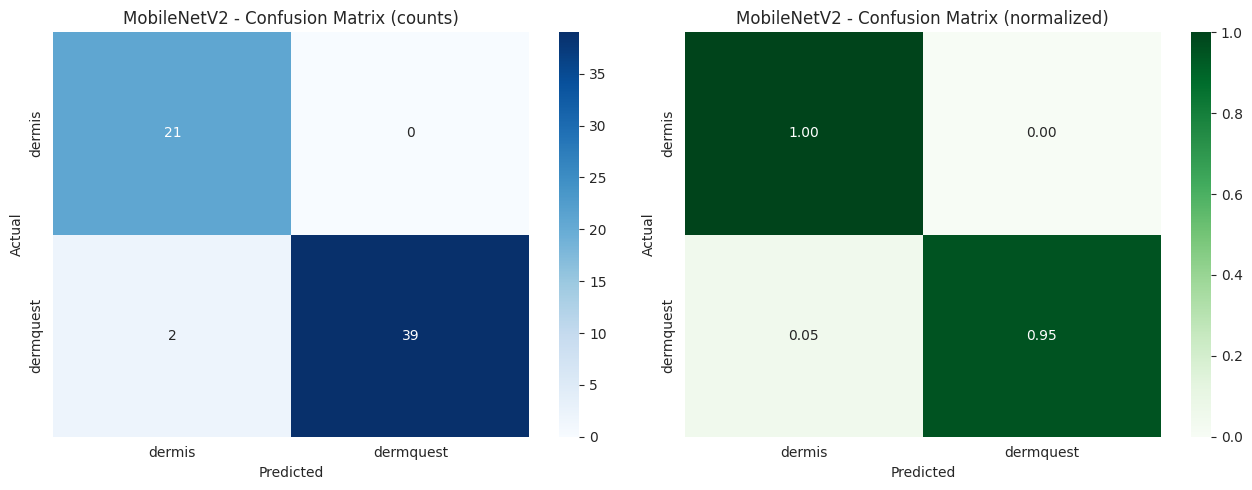


=============== EfficientNetB0 ===============
              precision    recall  f1-score   support

      dermis     0.9444    0.8095    0.8718        21
   dermquest     0.9091    0.9756    0.9412        41

    accuracy                         0.9194        62
   macro avg     0.9268    0.8926    0.9065        62
weighted avg     0.9211    0.9194    0.9177        62



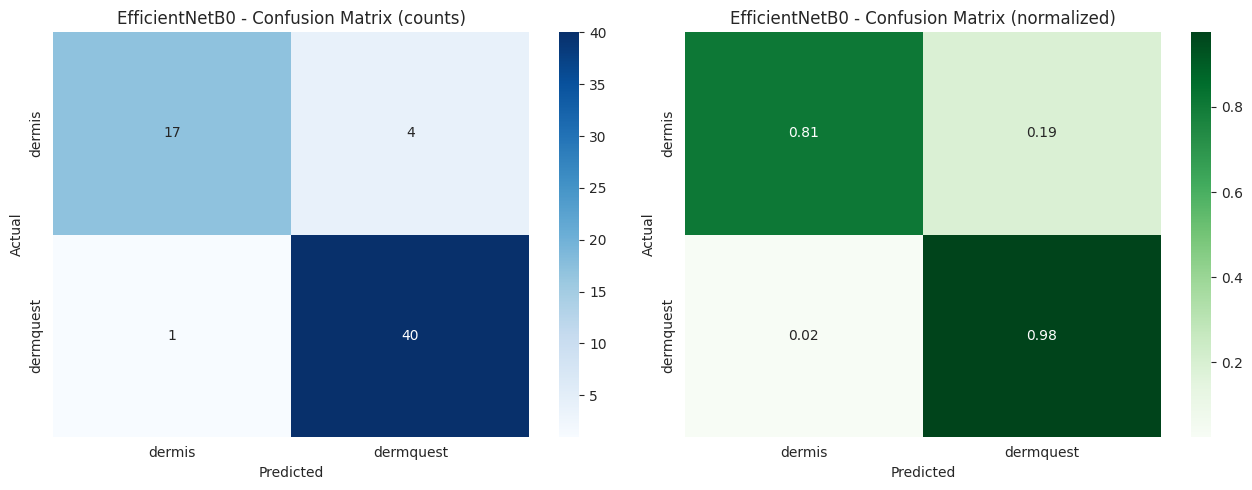

In [44]:
y_true = test_df.y.values
results, preds_store = [], {}

for name, model in models.items():
    probs = model.predict(test_ds, verbose=0)
    y_pred = probs.argmax(1)
    preds_store[name] = (y_pred, probs)

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Params (M)": model.count_params() / 1e6,
    }
    if NUM_CLASSES == 2:
        fpr, tpr, _ = roc_curve(y_true, probs[:, 1])
        row["ROC AUC"] = auc(fpr, tpr)
    results.append(row)

    print(f"\n{'='*15} {name} {'='*15}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax[0])
    ax[0].set_title(f"{name} - Confusion Matrix (counts)")
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", xticklabels=class_names, yticklabels=class_names, ax=ax[1])
    ax[1].set_title(f"{name} - Confusion Matrix (normalized)")
    for a in ax:
        a.set_xlabel("Predicted"); a.set_ylabel("Actual")
    plt.tight_layout(); plt.show()

results_df = pd.DataFrame(results).set_index("Model")

## 8. Results Visualization & Comparison

,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),Params (M),ROC AUC
Model,,,,,,,
Custom CNN,0.6129,0.6029,0.6144,0.5978,0.6229,0.2194,0.5273
MobileNetV2,0.9677,0.9565,0.9756,0.9648,0.9681,2.2605,0.9907
EfficientNetB0,0.9194,0.9268,0.8926,0.9065,0.9177,4.0521,0.9814


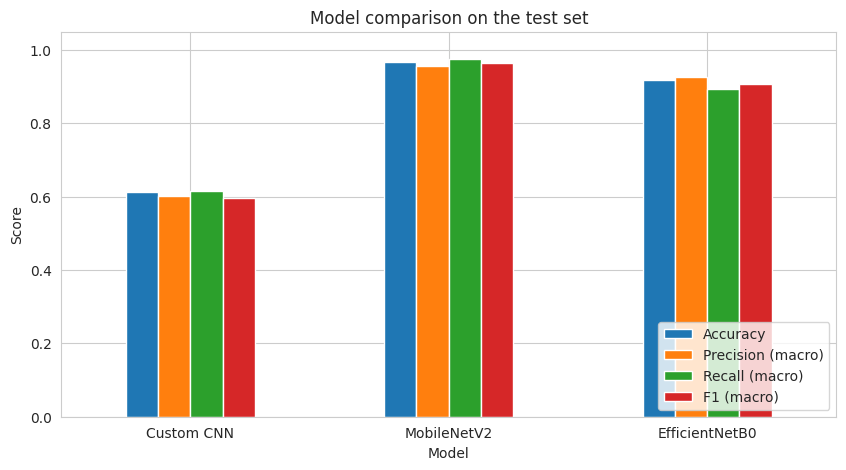

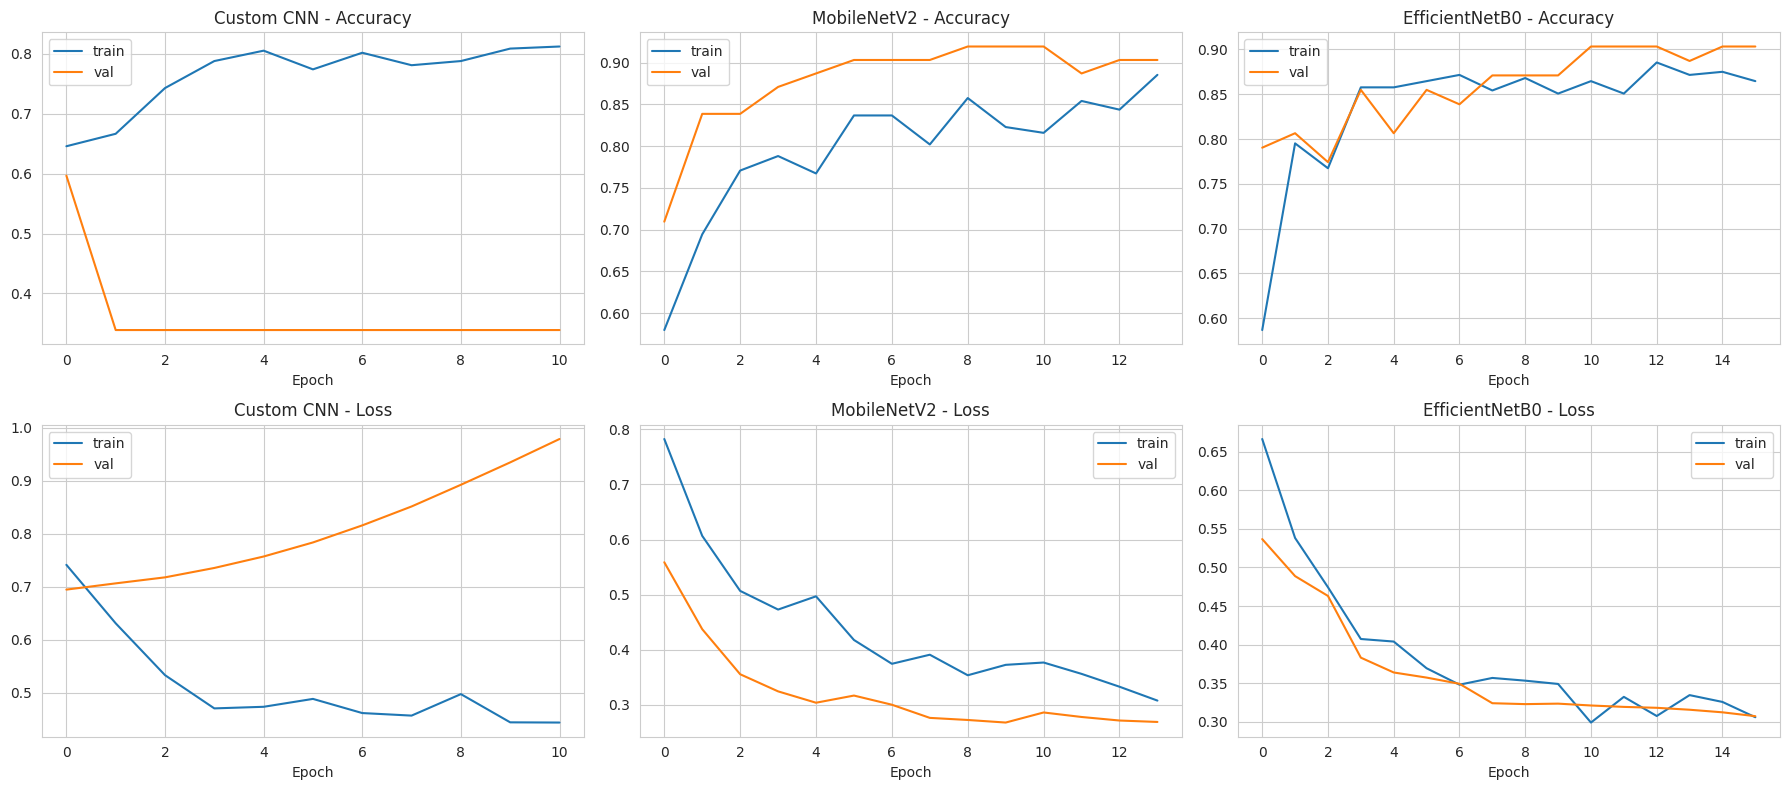

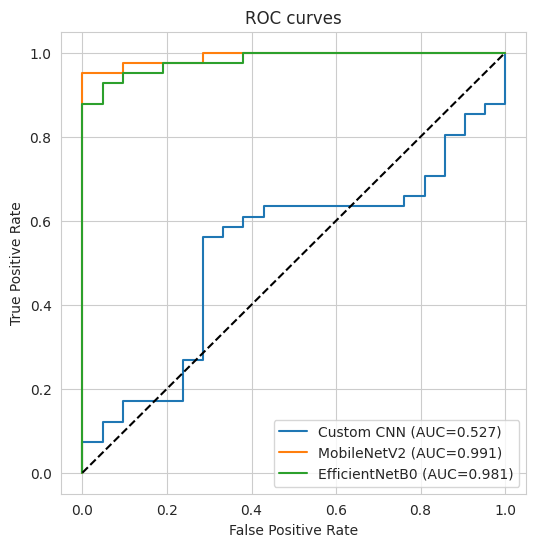

Best model (by macro F1): MobileNetV2


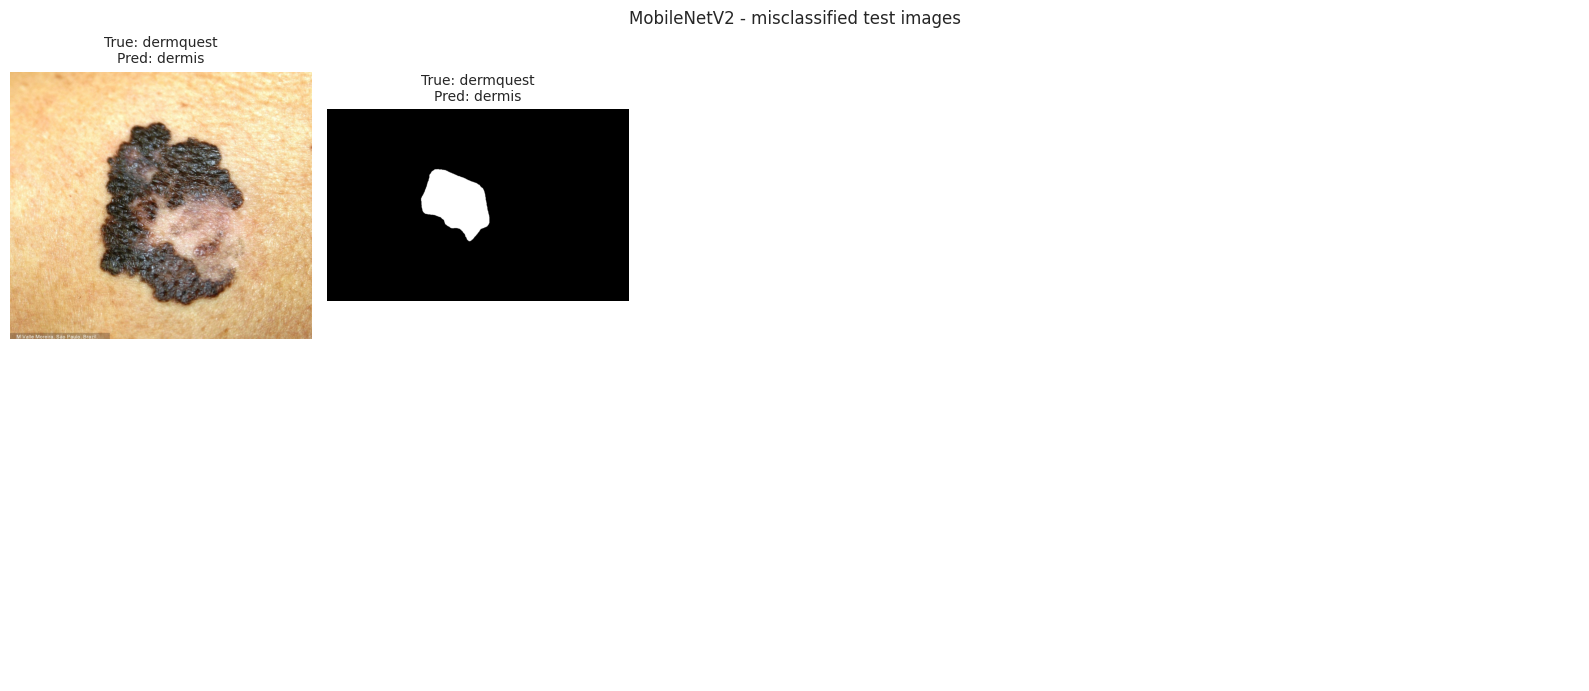

In [45]:
display(results_df.style.format("{:.4f}").background_gradient(cmap="YlGn", axis=0))

metric_cols = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]
results_df[metric_cols].plot(kind="bar", figsize=(10, 5), ylim=(0, 1.05), rot=0)
plt.title("Model comparison on the test set"); plt.ylabel("Score"); plt.legend(loc="lower right"); plt.show()

# Training curves
fig, ax = plt.subplots(2, len(histories), figsize=(6 * len(histories), 8), squeeze=False)
for i, (name, h) in enumerate(histories.items()):
    ax[0, i].plot(h["accuracy"], label="train"); ax[0, i].plot(h["val_accuracy"], label="val")
    ax[0, i].set_title(f"{name} - Accuracy"); ax[0, i].set_xlabel("Epoch"); ax[0, i].legend()
    ax[1, i].plot(h["loss"], label="train"); ax[1, i].plot(h["val_loss"], label="val")
    ax[1, i].set_title(f"{name} - Loss"); ax[1, i].set_xlabel("Epoch"); ax[1, i].legend()
plt.tight_layout(); plt.show()

# ROC curves (binary problems only)
if NUM_CLASSES == 2:
    plt.figure(figsize=(6, 6))
    for name, (_, probs) in preds_store.items():
        fpr, tpr, _ = roc_curve(y_true, probs[:, 1])
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
    plt.plot([0, 1], [0, 1], "k--"); plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC curves"); plt.legend(); plt.show()

# Misclassified examples from the best model
best_name = results_df["F1 (macro)"].idxmax()
print("Best model (by macro F1):", best_name)
y_pred_best = preds_store[best_name][0]
wrong = np.where(y_pred_best != y_true)[0]
show = wrong[:10]
if len(show):
    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    for a, idx in zip(axes.ravel(), show):
        a.imshow(Image.open(test_df.filepath[idx]).convert("RGB"))
        a.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred_best[idx]]}", fontsize=10)
        a.axis("off")
    for a in axes.ravel()[len(show):]:
        a.axis("off")
    plt.suptitle(f"{best_name} - misclassified test images"); plt.tight_layout(); plt.show()

## 9. Best Model Download for Streamlit Cloud Deployment
Exports the best model, class labels, a ready-to-use `app.py`, `requirements.txt`, and zips everything.

In [46]:
EXPORT_DIR = Path("/content/streamlit_deploy")
if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)
EXPORT_DIR.mkdir(parents=True)

best_model = models[best_name]
best_model.save(EXPORT_DIR / "skin_cancer_model.keras")

with open(EXPORT_DIR / "class_names.json", "w") as f:
    json.dump({"class_names": class_names, "img_size": IMG_SIZE, "best_model": best_name}, f, indent=2)

app_code = r'''import json
import numpy as np
import streamlit as st
import tensorflow as tf
from PIL import Image

st.set_page_config(page_title="Skin Cancer Detection", page_icon="🩺", layout="centered")

@st.cache_resource
def load_assets():
    model = tf.keras.models.load_model("skin_cancer_model.keras", compile=False)
    with open("class_names.json") as f:
        meta = json.load(f)
    return model, meta["class_names"], meta["img_size"]

model, class_names, img_size = load_assets()

st.title("🩺 Skin Cancer Detection")
st.write("Upload a skin lesion image to get a model prediction.")
st.warning("This is an educational demo, not a medical device. It cannot replace a diagnosis by a qualified doctor.")

file = st.file_uploader("Choose an image", type=["jpg", "jpeg", "png"])
if file is not None:
    image = Image.open(file).convert("RGB")
    st.image(image, caption="Uploaded image", use_container_width=True)
    x = np.expand_dims(np.asarray(image.resize((img_size, img_size)), dtype="float32"), 0)
    probs = model.predict(x, verbose=0)[0]
    top = int(np.argmax(probs))
    st.subheader(f"Prediction: {class_names[top]}")
    st.write(f"Confidence: {probs[top] * 100:.2f}%")
    st.bar_chart({c: float(p) for c, p in zip(class_names, probs)})
'''
(EXPORT_DIR / "app.py").write_text(app_code)

(EXPORT_DIR / "requirements.txt").write_text(
    f"streamlit\ntensorflow-cpu=={tf.__version__}\npillow\nnumpy\n"
)

(EXPORT_DIR / "README.md").write_text(
    "# Skin Cancer Detection - Streamlit app\n\n"
    "1. Push these files to a GitHub repo (keep them in the repo root).\n"
    "2. On share.streamlit.io create a new app pointing to `app.py`.\n"
    "3. In Advanced settings choose Python 3.11 or 3.12 (TensorFlow does not support the newest Python versions).\n"
)

# Sanity check: reload the exported model and compare with the in-memory one
reloaded = keras.models.load_model(EXPORT_DIR / "skin_cancer_model.keras", compile=False)
xb, _ = next(iter(test_ds))
diff = np.abs(reloaded.predict(xb, verbose=0) - best_model.predict(xb, verbose=0)).max()
print(f"Reload check - max prediction difference: {diff:.2e}")

size_mb = (EXPORT_DIR / "skin_cancer_model.keras").stat().st_size / 1e6
print(f"Model size: {size_mb:.1f} MB  (GitHub's file limit is 100 MB)")

zip_path = shutil.make_archive("/content/streamlit_deploy", "zip", EXPORT_DIR)
print("Created:", zip_path)

results_df.to_csv("/content/model_comparison.csv")

try:
    from google.colab import files
    files.download(zip_path)
    files.download("/content/model_comparison.csv")
except ImportError:
    print("Not running in Colab - files are saved at /content/")

Reload check - max prediction difference: 0.00e+00
Model size: 21.8 MB  (GitHub's file limit is 100 MB)
Created: /content/streamlit_deploy.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>